# Imaging, part 3: a Gaussian-process prior

Part 2 reconstructed the ring with maximum entropy, a penalty whose weight had to be swept and chosen. This part uses a **Gaussian-process (GP) prior** instead. The log-brightness of the image is modelled as a smooth random field about a template image, with two physical hyperparameters:
- **σ**, how far the log-brightness may wander from the template;
- **ℓ**, the correlation length: how far apart two pixels must be before they vary independently.

Three things make this attractive:
1. **The MAP is a least-squares fit.** virgil writes the field in whitened form, so the prior on its coefficients is a standard normal and becomes ordinary residuals. `fit` then uses Levenberg–Marquardt, which converges in a few dozen steps.
2. **The hyperparameters come from the data.** The **Bayesian evidence**, the probability of the data with the image integrated over, ranks pairs of σ and ℓ. There is no L-curve to read.
3. **The error bars can be checked.** The same machinery re-estimates whether they are too large or too small.

In [1]:
import sys
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as onp
import numpyro.distributions as dist
from tqdm.auto import tqdm

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from virgil.coverage import ami_grid_record
from virgil.fields import GaussianField
from virgil.fitting import fit
from virgil.imaging import MaxEntropy, beam, error_scale, image_priors, l_curve, log_evidence, starting_image
from virgil.models import Image, PointSource, System
from virgil.oidata import OIData
from virgil.plotting import plot_model, plot_residual_map
from virgil.scenes import ring

# The same scene and data as parts 1 and 2.
template = OIData(ami_grid_record(wavelength_m=4.8e-6, rotation_deg=-6.9))
npix, pixel_scale = 64, 20.0
fov = npix * pixel_scale
truth_image = ring(npix, pixel_scale, radius_mas=240.0, width_mas=36.0, inc_deg=50.0, pa_deg=30.0, asymmetry=0.6, asymmetry_pa_deg=90.0)
truth = System(star=PointSource(), dust=Image.from_brightness(truth_image, pixel_scale, flux=0.05))
data = template.with_model(truth, key=jax.random.PRNGKey(1))
resolution = beam(data)

# starting_image supplies the grid, the hole under the star, the flux, and a
# Gaussian template for the field to vary about.
start = starting_image(data, largest_mas=fov, hole_mas=0.5 * resolution.minor_mas)
n, h = start.env.log_brightness.shape[0], start.env.pixel_scale_mas
gaussian_template = onp.asarray(start.env.brightness)
print(f"{n}² pixels of {h:.1f} mas; beam {resolution.major_mas:.0f} × {resolution.minor_mas:.0f} mas")

62² pixels of 20.9 mas; beam 154 × 131 mas


## What the prior looks like

`GaussianField(latent, sigma, length_mas, mean=template)` writes the log-brightness as

$$\eta = \log\left(\frac{\mu}{\max\mu} + \epsilon\right) + \mathrm{IDCT}\left[\sqrt{S}\odot z\right].$$

- **μ** is the template: here `starting_image`'s Gaussian.
- **IDCT** is the inverse cosine transform, which diagonalises the Laplacian with reflecting edges.
- **S** is a Matérn-like spectrum, S ∝ (1/ℓ² + k²)⁻², scaled so that the field's variance is σ².
- **z** are the latents, with standard-normal priors.

Setting z = 0 gives the template, and z drawn from the prior gives an image from the prior. Here are prior draws with the same latents at three correlation lengths: short ℓ gives speckle, long ℓ gives broad clumps. Exponentiating the field makes the bright parts dominate.

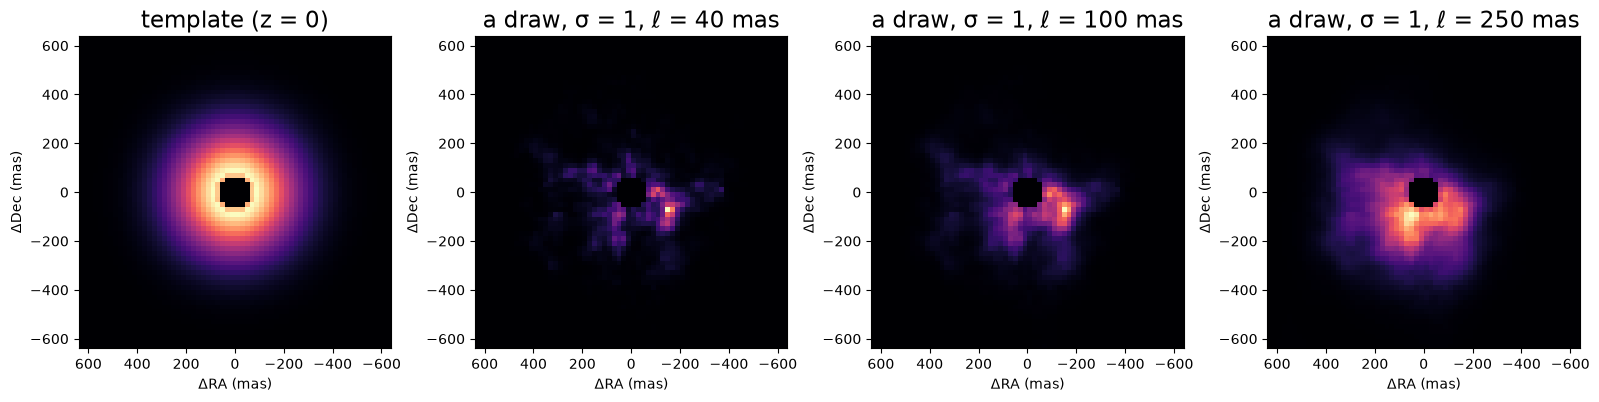

In [2]:
latent = jax.random.normal(jax.random.PRNGKey(0), (n, n))
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
plot_model(Image(GaussianField(onp.zeros((n, n)), mean=gaussian_template), h), fov_mas=fov, npix=npix, ax=axes[0], title="template (z = 0)")
for ax, length in zip(axes[1:], (40.0, 100.0, 250.0)):
    draw = Image(GaussianField(latent, sigma=1.0, length_mas=length, mean=gaussian_template), h)
    plot_model(draw, fov_mas=fov, npix=npix, ax=ax, title=f"a draw, σ = 1, ℓ = {length:.0f} mas")
plt.tight_layout()
plt.show()

## One MAP fit

The GP image replaces the pixel image of part 2. `image_priors` now gives the field's latents standard-normal priors, and needs no regulariser: the prior is the regulariser. Every term of the loss is then a least-squares residual, so `fit` uses Levenberg–Marquardt (LM). The image's flux is fitted too.

Here is one fit, at σ = 2 and ℓ = half the beam's minor axis.

In [3]:
def gp_scene(sigma, length):
    field = GaussianField(onp.zeros((n, n)), sigma, length, mean=gaussian_template)
    return System(star=PointSource(), env=Image(field, h, support=start.env.support, flux=start.env.flux))


flux_prior = {"env.flux": dist.LogUniform(1e-3, 2.0)}
scene = gp_scene(2.0, 0.5 * resolution.minor_mas)
one = fit(scene, image_priors(scene) | flux_prior, data)
print(f"{one.info['method']}: converged {one.info['converged']} in {one.info['steps']} steps; chi2 per point {one.info['chi2_red']:.3f}; flux {float(one.values['env.flux']):.4f} (truth 0.05)")

lm: converged True in 37 steps; chi2 per point 1.023; flux 0.0507 (truth 0.05)


## Choosing σ and ℓ from the evidence

`log_evidence(model, data)` is the Laplace approximation to the evidence at a MAP fit:

$$\log Z \approx -\tfrac{1}{2}\chi^2 - \tfrac{1}{2}|z|^2 - \tfrac{1}{2}\log\det\left(I + J^\top J\right).$$

- The first term rewards fitting the data.
- The second penalises latents that wander from the prior.
- The third is the Occam factor, which penalises a prior so loose that the data must pin down many parameters. Here J is the Jacobian of the whitened residuals with respect to the latents.

The pair with the largest evidence wins. ℓ is gridded in units of the beam, so the same grid suits any data. Each fit starts from the previous one. The grid is wide enough that the maximum lies inside it; if it falls on an edge, extend the grid in that direction. Expect a ridge rather than a sharp peak: a larger σ trades against a longer ℓ, because both let the field carry more structure.

ℓ:   0%|          | 0/4 [00:00<?, ?it/s]

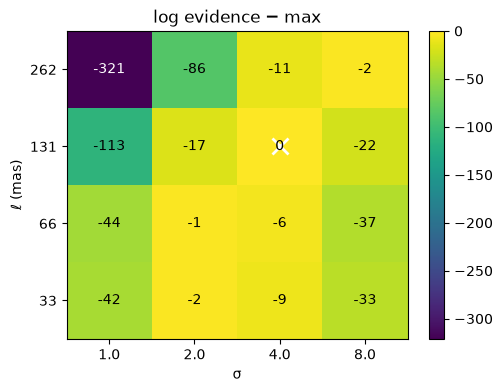

best: σ = 4.0, ℓ = 131 mas; all fits converged: True


In [4]:
lengths = [f * resolution.minor_mas for f in (0.25, 0.5, 1.0, 2.0)]
sigmas = [1.0, 2.0, 4.0, 8.0]
log_z, gp, previous = onp.zeros((4, 4)), {}, None
for i, length in enumerate(tqdm(lengths, desc="ℓ")):
    for j, sigma in enumerate(sigmas):
        scene = gp_scene(sigma, length)
        gp[i, j] = previous = fit(scene, image_priors(scene) | flux_prior, data, init=None if previous is None else previous.values)
        log_z[i, j] = log_evidence(gp[i, j].model, data)
best = onp.unravel_index(onp.argmax(log_z), log_z.shape)

fig, ax = plt.subplots(figsize=(5.5, 4))
im = ax.imshow(log_z - log_z.max(), origin="lower", cmap="viridis", aspect="auto")
ax.set(xticks=range(4), xticklabels=sigmas, yticks=range(4), yticklabels=[f"{l:.0f}" for l in lengths], xlabel="σ", ylabel="ℓ (mas)", title="log evidence − max")
middle = 0.5 * (log_z - log_z.max()).min()
for (a, b), value in onp.ndenumerate(log_z - log_z.max()):
    ax.text(b, a, f"{value:.0f}", ha="center", va="center", color="k" if value > middle else "w")
ax.plot(best[1], best[0], "wx", ms=12, mew=2)
plt.colorbar(im, ax=ax)
plt.show()
print(f"best: σ = {sigmas[best[1]]}, ℓ = {lengths[best[0]]:.0f} mas; all fits converged: {all(r.info['converged'] for r in gp.values())}")

## Are the error bars right?

The evidence, like the discrepancy principle, trusts the error bars. `error_scale(model, data)` checks them by treating the noise level as one more hyperparameter. Maximising the evidence over it gives MacKay's re-estimate:

$$s^2 = \frac{\chi^2}{N - \gamma}, \qquad \gamma = \sum_i \frac{\lambda_i / s^2}{1 + \lambda_i / s^2}.$$

Here λᵢ are the eigenvalues of JᵀJ with the quoted errors, so λᵢ/s² are those with the rescaled ones, and γ is the effective number of parameters the data measure. Each one absorbs a datum's worth of scatter, so honest error bars give χ² ≈ N − γ rather than N, and s ≈ 1. Since γ depends on s, `error_scale` solves the equation for s.

These simulated data have honest errors. For contrast, the same truth is also simulated with only half as much noise as the error bars claim, which is like overestimated errors on real data. Rescaling those data by s (`OIData.with_error_scale`) and refitting brings the estimate back to about one. The `error_scale` docstring gives the derivation and references.

In [5]:
best_scene = gp_scene(sigmas[best[1]], lengths[best[0]])
best_fit = gp[best]
print(f"honest errors: s = {error_scale(best_fit.model, data):.2f}")

overstated = template.with_model(truth, key=jax.random.PRNGKey(1), noise_scale=0.5)
first = fit(best_scene, image_priors(best_scene) | flux_prior, overstated)
s = error_scale(first.model, overstated)
rescaled = overstated.with_error_scale(s)
second = fit(best_scene, image_priors(best_scene) | flux_prior, rescaled)
print(f"errors overstated twofold: chi2 per point {first.info['chi2_red']:.2f}, s = {s:.2f}; after rescaling, s = {error_scale(second.model, rescaled):.2f}")

honest errors: s = 1.04


errors overstated twofold: chi2 per point 0.26, s = 0.53; after rescaling, s = 0.98


## The GP image against maximum entropy

Here are the GP image at the evidence's σ and ℓ, and the maximum-entropy image of part 2 at its discrepancy weight, each with the beam shaded, and below them their signed differences from the truth. They are MAP images, so the differences are not z-scores. On this well-sampled AMI scene the two are about equally good. The GP prior's advantages are speed and the principled choice of its hyperparameters; on sparser long-baseline data it also gives higher fidelity (see `notebooks/mwe/mwe_gaussian_field.ipynb`).

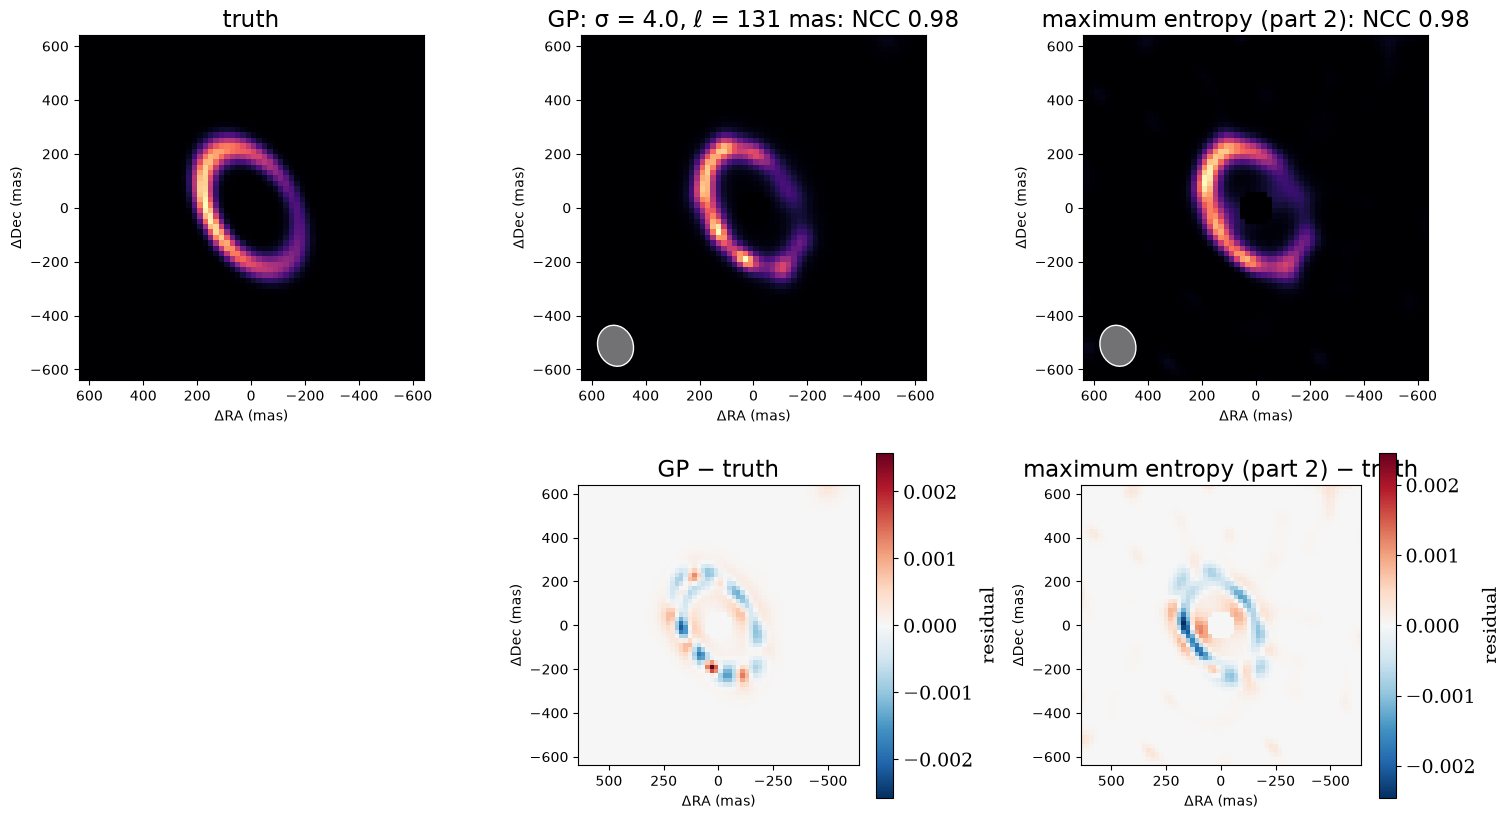

In [6]:
def ncc(a, b):
    a, b = a - a.mean(), b - b.mean()
    return float(jnp.sum(a * b) / jnp.sqrt(jnp.sum(a * a) * jnp.sum(b * b)))


mem_start = starting_image(data, largest_mas=fov, hole_mas=0.5 * resolution.minor_mas)
curve = l_curve(mem_start, image_priors(mem_start) | flux_prior, data, MaxEntropy(1.0, path="env"), jnp.logspace(3.5, 1.0, 11), max_steps=200_000)
mem = curve.results[int(jnp.argmin(jnp.abs(jnp.log(curve.weights) - jnp.log(curve.discrepancy()))))]

fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
plot_model(truth.dust, fov_mas=fov, npix=npix, ax=axes[0, 0], title="truth")
axes[1, 0].axis("off")
for column, (name, r) in enumerate([(f"GP: σ = {sigmas[best[1]]}, ℓ = {lengths[best[0]]:.0f} mas", best_fit), ("maximum entropy (part 2)", mem)], start=1):
    image = r.model.env.render(npix, fov)
    plot_model(r.model.env, fov_mas=fov, npix=npix, ax=axes[0, column], title=f"{name}: NCC {ncc(image, truth_image):.2f}", beam=resolution)
    plot_residual_map(image - truth_image, fov_mas=fov, ax=axes[1, column], title=name.split(":")[0] + " − truth")
plt.tight_layout()
plt.show()

## Summary

A Gaussian-process prior turns image reconstruction into a well-posed Bayesian problem:
- **A field object.** `GaussianField` makes the log-brightness a smooth random field about a template. With `image_priors`' standard-normal latents, the MAP is a fast Levenberg–Marquardt fit.
- **Hyperparameters from the data.** `log_evidence` ranks σ and ℓ, and gridding ℓ in units of the beam keeps the grid sensible for any data.
- **A check on the error bars.** `error_scale` estimates how wrong they are, and `OIData.with_error_scale` corrects them before the hyperparameters are chosen.

The same parameterisation suits sampling the posterior with numpyro's NUTS (`likelihood.numpyro_model`), which gives uncertainty maps and z-score residuals. Part 4 puts a GP image next to other analytic components, a ring around a binary star.